In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings("ignore")

from common import basedir
from training_configuration import PATHWAYS_BY_FIGURE
from figure_config import (
    MODEL_LABELS,
    MODEL_COLORS,
    MODEL_GROUPS,
    CONTEXT_LABELS,
    BARPLOT_CONTEXT_ORDER,
    BARPLOT_REF_LINE_STYLES,
    BARPLOT_REF_LINE_COLORS,
    AXIS_SPINE_LINEWIDTH,
    AXIS_SPINE_COLOR,
    REF_DISPLAY_MAP,
    configure_axis_spines,
 )


def load_figure_data(figure: str, data: str = "dream_cytof"):
    """Load evaluation data for a specific figure.

    Args:
        figure: Figure name (e.g., 'figure1a', 'figure2', 'figure3')
        data: Dataset name

    Returns:
        DataFrame with all evaluation results for the figure
    """
    evaluations_dir = basedir / "eval"
    pathways = PATHWAYS_BY_FIGURE.get(figure, [])

    dfs = []
    for model in pathways:
        filepath = evaluations_dir / model / data / f"evaluate_all_{figure}.csv"
        if filepath.exists():
            dfs.append(
                pd.read_csv(filepath, index_col=0).assign(model=model)
            )

    if not dfs:
        raise ValueError(f"No data found for figure '{figure}'")

    return pd.concat(dfs)



def _add_group_padding(hue_order, padding_width=0.5):
    """Add padding entries between model groups.

    Args:
        hue_order: List of model labels
        padding_width: Not used directly, but padding is added as empty string entries

    Returns:
        tuple: (padded_hue_order, padded_palette) with empty entries for spacing
    """
    padded_order = []
    padded_palette = []

    # Find which groups are present in hue_order
    current_group_idx = -1
    for label in hue_order:
        # Find which group this label belongs to
        label_group_idx = None
        for i, group in enumerate(MODEL_GROUPS):
            if label in group:
                label_group_idx = i
                break

        # Add padding if we're moving to a new group (not the first one)
        if label_group_idx is not None and label_group_idx != current_group_idx:
            if current_group_idx != -1:  # Don't add padding before first group
                padded_order.append("")  # Empty string for spacing
                padded_palette.append("white")  # Invisible color
            current_group_idx = label_group_idx

        padded_order.append(label)
        padded_palette.append(MODEL_COLORS.get(label, "#333333"))

    return padded_order, padded_palette


def _configure_boxplot_axis(ax, xlabel, ylabel, ylim, title, rotate_xticks=True):
    """Configure axis properties for boxplot subplots.

    Args:
        ax: Matplotlib axis object
        xlabel: X-axis label
        ylabel: Y-axis label
        ylim: Y-axis limits tuple
        title: Subplot title
        rotate_xticks: Whether to rotate x-tick labels 45 degrees
    """
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_ylim(ylim)
    ax.set_title(title)
    if rotate_xticks:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Apply shared axis styling
    configure_axis_spines(ax)


def _plot_boxplot(ax, plot_df, contexts, hue_order):
    """Plot a boxplot on the given axis.

    Args:
        ax: Matplotlib axis object
        plot_df: DataFrame with plotting data
        contexts: List of contexts for x-axis order
        hue_order: Order of hue categories
    """
    # Add padding between model groups
    padded_hue_order, padded_palette = _add_group_padding(hue_order)

    # Add dummy rows for padding entries
    plot_df = plot_df.copy()
    for padding_label in [h for h in padded_hue_order if h == ""]:
        # Add a dummy row with NaN rmse for each context
        for ctx in contexts:
            dummy_row = pd.DataFrame({
                "context": [ctx],
                "rmse": [np.nan],
                "model_label": [""]
            })
            plot_df = pd.concat([plot_df, dummy_row], ignore_index=True)

    sns.boxplot(
        data=plot_df,
        x="context",
        y="rmse",
        hue="model_label",
        hue_order=padded_hue_order,
        order=contexts,
        palette=padded_palette,
        ax=ax
    )


def _add_reference_lines(ax, ref_df, ref_lines, with_uncertainty=False):
    """Add horizontal reference lines to the axis.

    Args:
        ax: Matplotlib axis object
        ref_df: DataFrame with reference data
        ref_lines: Reference types to show as horizontal lines
    """
    for ref_type in ref_lines:
        ref_subset = ref_df[ref_df.ref == ref_type]
        if len(ref_subset) > 0:
            mean_rmse = ref_subset["rmse"].mean()
            std_rmse = ref_subset["rmse"].std()
            color = BARPLOT_REF_LINE_COLORS.get(ref_type, "gray")
            linestyle = BARPLOT_REF_LINE_STYLES.get(ref_type, "--")

            # Add shading for the range (mean ± std)
            if with_uncertainty:
                ax.axhspan(
                    mean_rmse - std_rmse,
                    mean_rmse + std_rmse,
                    color=color,
                    alpha=0.15,
                    linewidth=0
                )

            # Add the mean line
            ax.axhline(
                y=mean_rmse,
                color=color,
                linestyle=linestyle,
                linewidth=3,
                label=ref_type
            )


def _prepare_data(df, contexts, models, refs, ref_lines):
    """Prepare data for plotting.

    Args:
        df: DataFrame with data
        contexts: List of contexts to include
        models: List of models to include
        refs: Reference types to include in boxplot
        ref_lines: Reference types to show as horizontal lines

    Returns:
        tuple: (plot_df, ref_df, hue_order, contexts, models)
    """
    # Default context order
    default_context_order = BARPLOT_CONTEXT_ORDER

    # Extract unique contexts and models from data if not specified
    if contexts is None:
        available_contexts = df[df.ref == "DMM"]["context"].unique().tolist()
        contexts = [c for c in default_context_order if c in available_contexts]
        contexts += [c for c in available_contexts if c not in contexts]
    if models is None:
        models = df[df.ref == "DMM"]["model"].unique().tolist()

    # Create model labels
    model_labels = {m: MODEL_LABELS.get(m, m) for m in models}
    if "elasticnet" in refs:
        model_labels["elasticnet"] = MODEL_LABELS.get("elasticnet")

    # Filter plot data for DMM
    plot_df = df[
        (df.ref == "DMM") &
        (df.context.isin(contexts)) &
        (df.model.isin(models))
    ].copy()
    plot_df["model_label"] = plot_df["model"].map(model_labels)

    # Add elasticnet data if requested
    if "elasticnet" in refs:
        elasticnet_df = df[
            (df.ref == "elasticnet") &
            (df.context.isin(contexts))
        ].copy()
        elasticnet_df["model_label"] = MODEL_LABELS.get("elasticnet")
        plot_df = pd.concat([plot_df, elasticnet_df], ignore_index=True)

    # Get reference values for horizontal lines
    ref_df = df[
        (df.ref.isin(ref_lines)) &
        (df.context.isin(contexts))
    ]

    # Hue order
    hue_order = [model_labels[m] for m in models if m in model_labels]
    if "elasticnet" in refs:
        hue_order.append(MODEL_LABELS.get("elasticnet"))

    return plot_df, ref_df, hue_order, contexts, models


def plot_model_comparison(
    df,
    figsize=(20, 6),
    ylim=(0.15, 1.0),
    refs=("DMM", "elasticnet"),
    ref_lines=("negative control", "positive control"),
    contexts=None,
    models=None,
    dataset="val",
    column_ratios=None,
    save_path=None,
    with_reference_uncertainty=False,
):
    """Plot model comparison boxplot with reference lines.

    Args:
        df: DataFrame with columns: ref, context, model, rmse, dataset, samples
        figsize: Figure size tuple
        ylim: Y-axis limits tuple
        refs: Reference types to include in boxplot (e.g., DMM, elasticnet)
        ref_lines: Reference types to show as horizontal lines (e.g., negative control, positive control)
        contexts: List of contexts to include (None = all from data)
        models: List of models to include (None = all from data)
        dataset: Which dataset(s) to use:
            - "val": validation set (samples != "all")
            - "test": test set (samples == "all")
            - ("val", "test"): show both side by side (4 columns)
        column_ratios: Custom width ratios for columns.
            - For single dataset: list of 3 values [left, plot, right] (default: [1, 1, 1])
            - For two datasets: list of 4 values [left, plot1, plot2, right] (default: [0.5, 1, 1, 0.5])
        save_path: Path to save the figure (None = don't save)
    """
    # Rename ref values for display
    df = df.copy()
    df["ref"] = df["ref"].replace(REF_DISPLAY_MAP)
    for context, label in CONTEXT_LABELS.items():
        df["context"] = df["context"].replace({context: label})
    df["context"] = df["context"].replace({"cytof_init": "CyTOF"})

    # Normalize dataset to a tuple
    if isinstance(dataset, str):
        datasets_to_plot = (dataset,)
    else:
        datasets_to_plot = tuple(dataset)

    # Prepare data for each dataset
    data_by_dataset = {}
    for ds in datasets_to_plot:
        title = r"Predictive Performance"
        if ds == "val":
            data_df = df[(df.dataset == "val") & (np.logical_not(df.samples.str.startswith('all')))].copy()
            if len(datasets_to_plot) > 1:
                title += r" ($\\bf{Validation}$ Set)"
        elif ds == "test":
            data_df = df[(df.dataset == "val") & (df.samples.str.startswith('all'))].copy()
            if len(datasets_to_plot) > 1:
                title += r" ($\\bf{Test}$ Set)"
        else:
            raise ValueError(f"Unknown dataset: {ds}. Use 'val', 'test', or a tuple like ('val', 'test').")

        data_df.features.fillna("None", inplace=True)
        plot_df, ref_df, hue_order, resolved_contexts, resolved_models = _prepare_data(
            data_df, contexts, models, refs, ref_lines
        )
        data_by_dataset[ds] = {
            "plot_df": plot_df,
            "ref_df": ref_df,
            "title": title,
        }
        # Use contexts/models from first dataset for consistency
        if contexts is None:
            contexts = resolved_contexts
        if models is None:
            models = resolved_models

    # Rebuild hue_order properly
    model_labels = {m: MODEL_LABELS.get(m, m) for m in models}
    hue_order = [model_labels[m] for m in models if m in model_labels]
    if "elasticnet" in refs:
        hue_order.append(MODEL_LABELS.get("elasticnet"))

    # Create figure layout based on number of datasets
    if len(datasets_to_plot) == 1:
        # 3-column layout: empty | plot | legend
        ratios = column_ratios if column_ratios is not None else [1, 1, 1]
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(1, 3, width_ratios=ratios)
        ax_left = fig.add_subplot(gs[0, 0])
        axes = [fig.add_subplot(gs[0, 1])]
        ax_right = fig.add_subplot(gs[0, 2])
    else:
        # 4-column layout: empty | plot1 | plot2 | legend
        ratios = column_ratios if column_ratios is not None else [0.5, 1, 1, 0.5]
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(1, 4, width_ratios=ratios)
        ax_left = fig.add_subplot(gs[0, 0])
        axes = [fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
        ax_right = fig.add_subplot(gs[0, 3])

    ax_left.axis('off')
    ax_right.axis('off')

    # Plot each dataset
    for i, ds in enumerate(datasets_to_plot):
        ax = axes[i]
        data = data_by_dataset[ds]

        _plot_boxplot(ax, data["plot_df"], contexts, hue_order)
        _add_reference_lines(ax, data["ref_df"], ref_lines, with_uncertainty=with_reference_uncertainty)

        # Only show ylabel on first plot
        ylabel = "RMSE" if i == 0 else ""
        _configure_boxplot_axis(ax, "Input Features (Baseline)", ylabel, ylim, data["title"])
        ax.legend().remove()

        # Remove y tick labels for second plot onwards
        if i > 0:
            ax.set_yticklabels([])

    # Place legend in the right subplot (use handles from first axis)
    handles, labels = axes[0].get_legend_handles_labels()
    ax_right.legend(handles, labels, loc='center left', frameon=False)

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    if len(axes) == 1:
        return fig, axes[0]
    return fig, tuple(axes)


def plot_figure6_features(
    figsize=(20, 6),
    ylim=(0.25, 0.75),
    ref_lines=("negative control", "positive control"),
    refs=("DMM + EGFR transcript levels", "linear regression"),
    column_ratios=None,
    save_path=None,
):
    """Plot figure 6: RMSE vs percentage of missing transcriptomics.

    Args:
        figsize: Figure size tuple
        ylim: Y-axis limits tuple
        ref_lines: Reference types to show as horizontal lines
        refs: Reference types to include in lineplot (e.g., DMM, Elastic Net)
        column_ratios: Custom width ratios for columns [left, plot, right] (default: [0.5, 1, 0.5])
        save_path: Path to save the figure (None = don't save)
    """
    df = load_figure_data("figure6")

    # Rename ref values for display
    df["ref"] = df["ref"].replace({
        "avg_model": "negative control",
        "sample": "positive control",
        "elasticnet": "linear regression",
        "DMM": "DMM + EGFR transcript levels"
    })

    # Filter to validation data only (exclude "all_plus_missingtx" base)
    data_df = df[
        (df.dataset == "val") &
        (df.ref.isin(refs)) &
        (df.samples.str.contains("pct"))
    ].copy()

    # Extract percentage and seed from samples column (e.g., "all_plus_missingtx_30pct_0" -> pct=30, seed=0)
    data_df[["pct_missing", "seed"]] = data_df["samples"].str.extract(r"_(\\d+)pct_(\\d+)")
    data_df["pct_missing"] = data_df["pct_missing"].astype(int)
    data_df["seed"] = data_df["seed"].astype(int)

    # Convert percentage to actual number of cell lines (61 total)
    data_df["n_cell_lines"] = (data_df["pct_missing"] / 100 * 61).round().astype(int)

    # Aggregate across seeds: mean RMSE per (n_cell_lines, seed, ref)
    data_df = data_df.groupby(["n_cell_lines", "seed", "ref"], as_index=False)["rmse"].mean()

    # Get reference values for horizontal lines
    ref_df = df[
        (df.dataset == "val") &
        (df.ref.isin(ref_lines))
    ]

    fig = plt.figure(figsize=figsize)
    ratios = column_ratios if column_ratios is not None else [0.5, 1, 0.5]
    gs = fig.add_gridspec(1, 3, width_ratios=ratios)
    ax_left = fig.add_subplot(gs[0, 0])  # Left column (empty)
    ax = fig.add_subplot(gs[0, 1])  # Middle column for the plot
    ax_right = fig.add_subplot(gs[0, 2])  # Right column (for legend)

    # Hide the left and right axes
    ax_left.axis('off')
    ax_right.axis('off')

    # Lineplot with number of cell lines on x-axis
    hue_order = [r for r in refs if r in data_df["ref"].unique()]
    palette = [MODEL_COLORS.get(label, "#333333") for label in hue_order]

    sns.lineplot(
        data=data_df,
        x="n_cell_lines",
        y="rmse",
        hue="ref",
        hue_order=hue_order,
        marker="o",
        errorbar="sd",
        palette=palette,
        ax=ax
    )

    # Add horizontal lines for reference types
    for ref_type in ref_lines:
        ref_subset = ref_df[ref_df.ref == ref_type]
        if len(ref_subset) > 0:
            mean_rmse = ref_subset["rmse"].mean()
            std_rmse = ref_subset["rmse"].std()
            color = BARPLOT_REF_LINE_COLORS.get(ref_type, "gray")
            linestyle = BARPLOT_REF_LINE_STYLES.get(ref_type, "--")

            # # Add shading for the range (mean ± std)
            # ax.axhspan(
            #     mean_rmse - std_rmse,
            #     mean_rmse + std_rmse,
            #     color=color,
            #     alpha=0.15,
            #     linewidth=0
            # )

            # Add the mean line
            ax.axhline(
                y=mean_rmse,
                color=color,
                linestyle=linestyle,
                linewidth=3,
                label=ref_type
            )

    ax.set_xlabel("Number of Cell Lines Used for Training")
    ax.set_ylabel("RMSE")
    ax.set_ylim(ylim)
    ax.set_title(r"Predictive Performance: Data Ablation")

    # Apply shared axis styling
    configure_axis_spines(ax)

    # Place legend in the right subplot
    handles, labels = ax.get_legend_handles_labels()
    ax.legend().remove()
    ax_right.legend(handles, labels, loc='center left', frameon=False)

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    return fig, ax

plot_figure6_features(save_path="DataAblation.png");


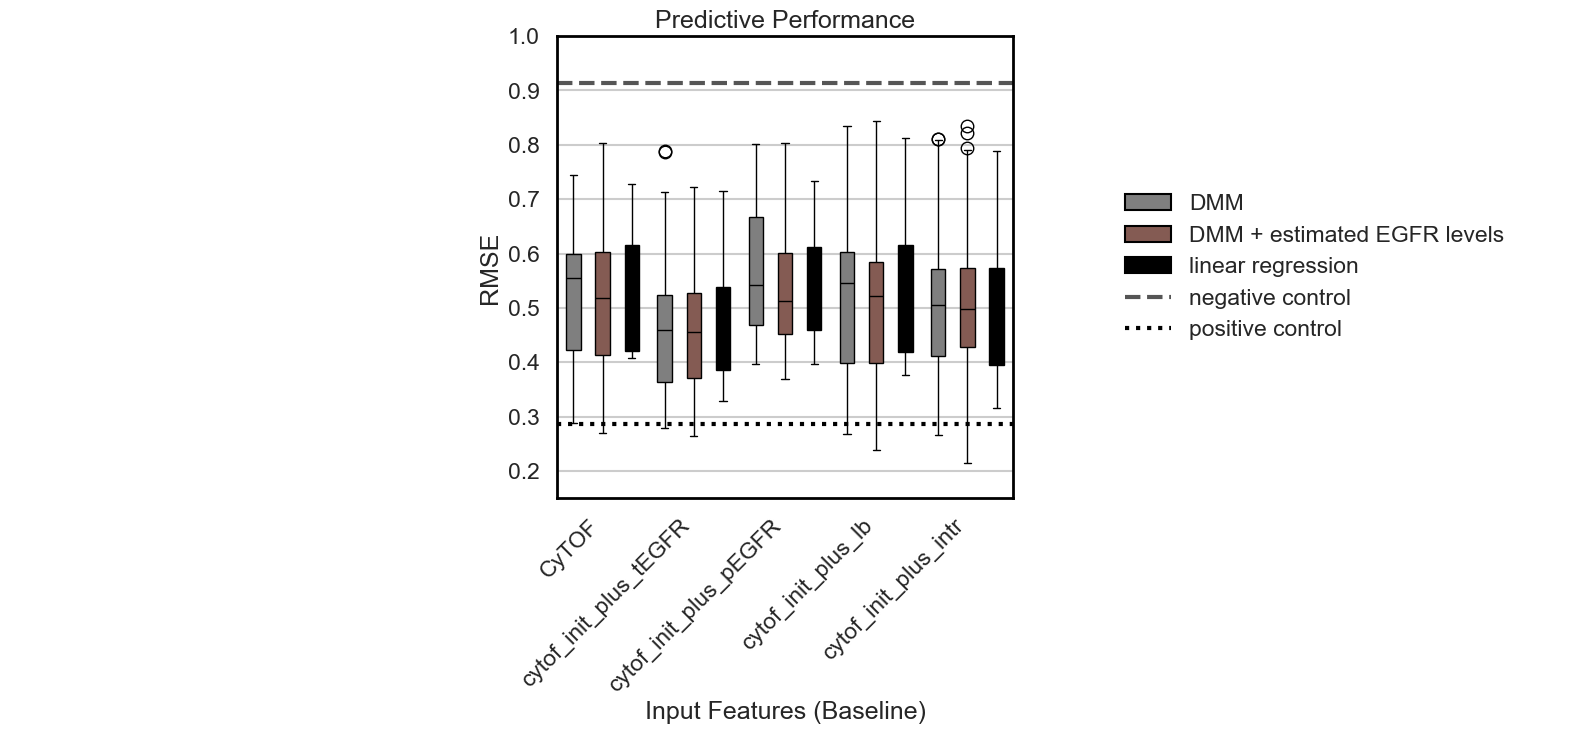

In [2]:
df_fig2 = load_figure_data("figure2")
plot_model_comparison(df_fig2);


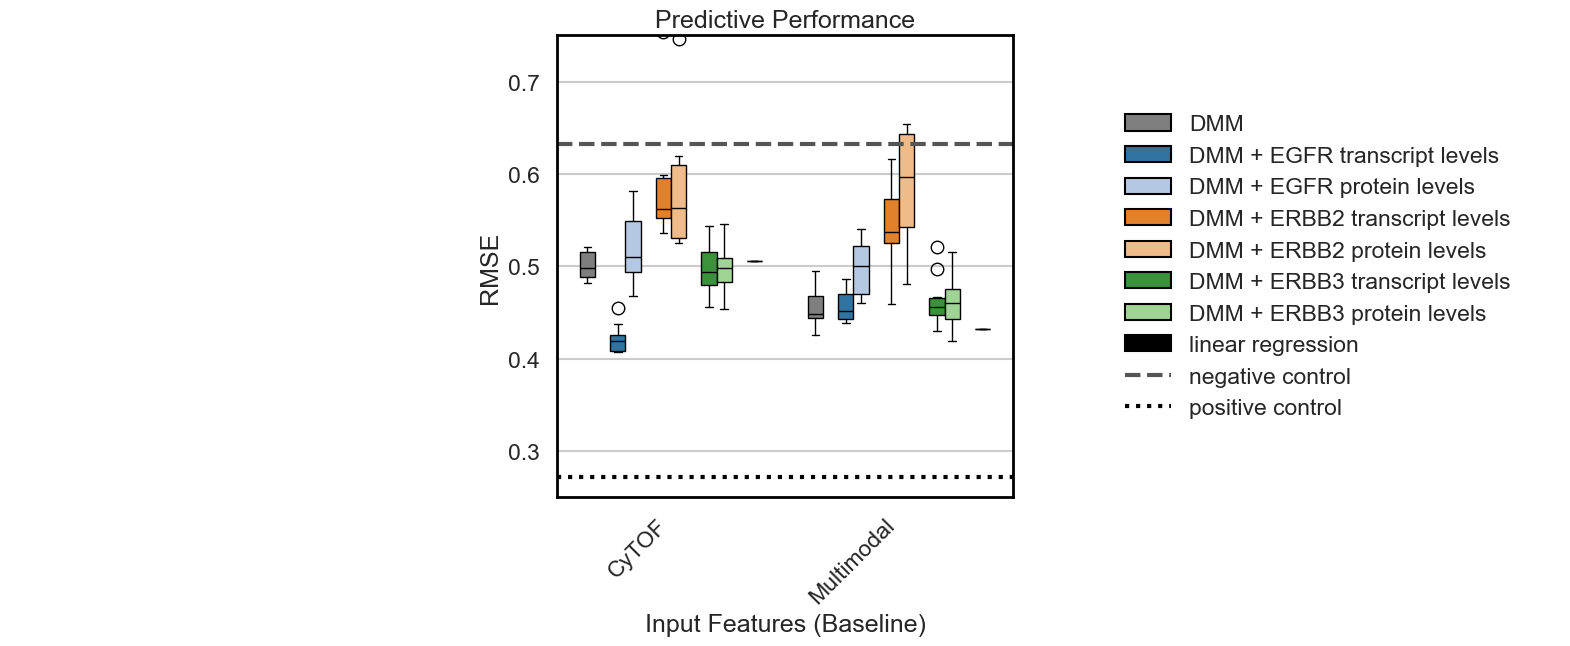

In [3]:
plot_model_comparison(
    load_figure_data("figure3"),
    refs=('DMM', 'elasticnet'),
    ylim=(0.25, 0.75),
    dataset="test",
    save_path="RTKComparison.png"
);

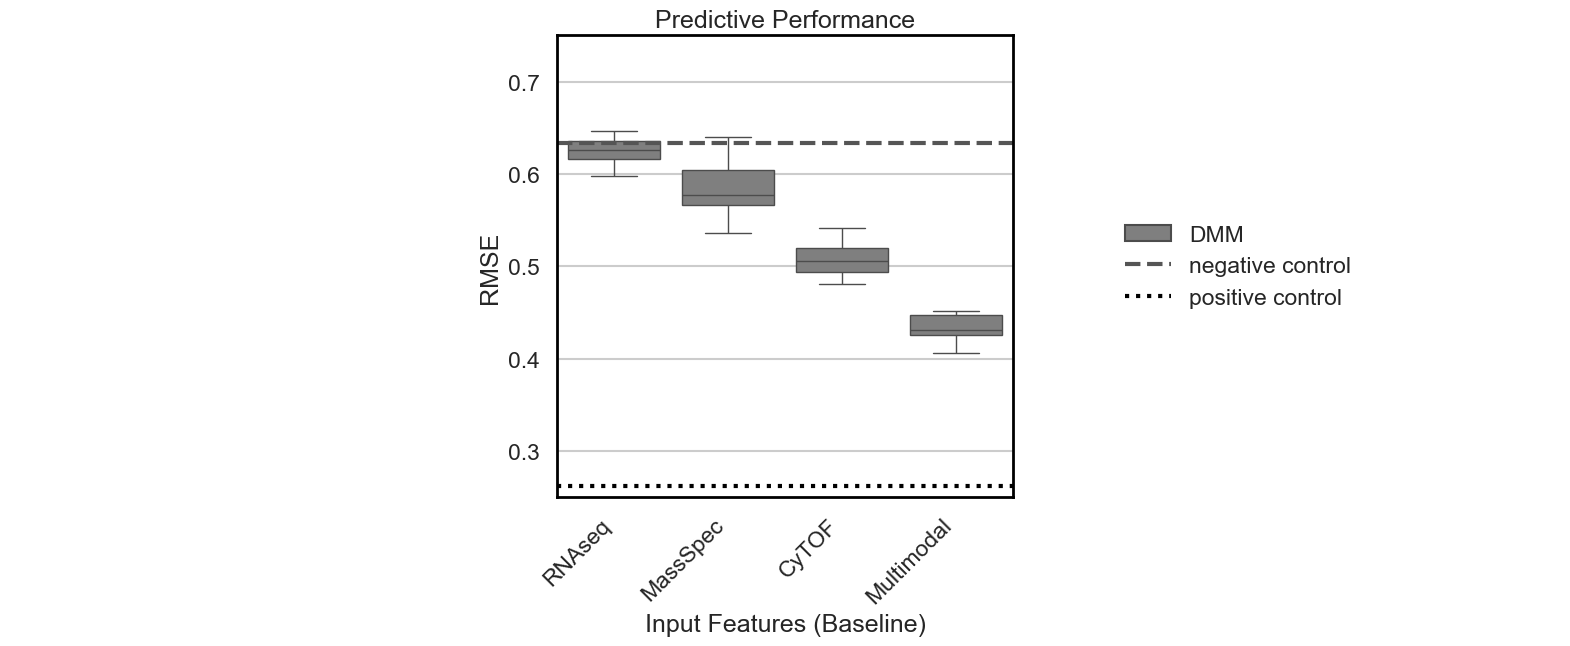

In [4]:
plot_model_comparison(
    load_figure_data("figure1a"),
    dataset=("test",),
    refs=("DMM",),
    ylim=(0.25, 0.75),
    models=["EGFR_MAPK__logobs"],
    save_path="InputModeComparison.png"
);